# Notebook 4 — Weather, Demand, and Renewable Variability

## Objective

This notebook investigates how weather conditions translate into Alberta electricity demand, wind generation, solar generation, and net load.

Notebook 2 established that net load and available system margin are important indicators of physical system tightness. Notebook 4 moves upstream of those results. It asks how temperature, wind, irradiance, cloud cover, snow, and compound weather conditions create the demand and renewable-output states observed by the power system.

The notebook examines:

- temperature and electricity-demand formation;
- wind speed and wind-generation availability;
- irradiance, clouds, snow, and solar generation;
- renewable ramps and persistent low-output conditions;
- compound weather conditions associated with extreme net load; and
- the distinction between explanatory weather observations and forecast-eligible weather inputs.

The analysis is descriptive and contemporaneous. ERA5 values represent observed reanalysis weather rather than operational weather forecasts. Actual load and renewable generation are realized outcomes and are not automatically forecast eligible.

The notebook does not repeat Notebook 2’s scarcity analysis, Notebook 5’s calendar and price-memory analysis, or the predictive modelling assigned to Notebooks 6–8.

## 1. Definitions and Analytical Framework

### 1.1. Imports and Canonical Dataset

The notebook uses the canonical hourly master dataset produced by the project pipeline. The `master` DataFrame remains authoritative, while Notebook 4 variables are stored separately in `weather_features`.

The study period covers Alberta operating years 2015–2025.

In [1]:
# ---------------------------------------------------------------------
# Configure imports and load the canonical master dataset
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

np.random.seed(RANDOM_SEED)

master = pd.read_parquet(MASTER_PARQUET)

print(
    f'Canonical master loaded: '
    f'{master.shape[0]:,} rows x '
    f'{master.shape[1]:,} columns'
)

Canonical master loaded: 96,425 rows x 494 columns


### 1.2 Study Period and Required Inputs

Timestamp integrity, coverage, reporting boundaries, and physical units are audited before the analysis begins.

The weather inputs have two distinct constructions:

- **Load-weighted weather** combines regional weather using actual hourly regional load shares.
- **Renewable capacity-weighted weather** combines project-level weather using the historically active wind or solar fleet.

Load-weighted weather is useful for historical explanation, but its actual same-hour regional weights are not directly forecast eligible. Renewable weather fields are also observed ERA5 reanalysis and must eventually be replaced by operational weather forecasts.

In [2]:
# ---------------------------------------------------------------------
# Define study period and required inputs
# ---------------------------------------------------------------------

STUDY_START_YEAR = 2015
STUDY_END_YEAR = 2025

ALBERTA_TIMEZONE = 'America/Edmonton'

TEMPERATURE_BIN_WIDTH_C = 2
WIND_SPEED_BIN_WIDTH_MS = 1
SOLAR_RADIATION_BIN_WIDTH_WM2 = 50

MINIMUM_BIN_HOURS = 100
MINIMUM_STATE_HOURS = 100

EXTREME_NET_LOAD_PERCENTILE = 0.99

REGIONAL_LOAD_COLUMNS = [
    "calgary_load_mw",
    "central_load_mw",
    "edmonton_load_mw",
    "northeast_load_mw",
    "northwest_load_mw",
    "south_load_mw",
]

LOAD_WEATHER_COLUMNS = [
    "load_weighted_temperature_c",
    "load_temperature_spatial_std_c",
    "load_temperature_min_c",
    "load_temperature_max_c",
    "load_weighted_relative_humidity_pct",
    "load_weighted_wind_chill_c",
    "load_weighted_heat_index_c",
    "load_weighted_wetbulb_c",
    "load_temperature_change_1h_c",
    "load_temperature_change_6h_c",
    "load_temperature_mean_24h_c",
]

WIND_WEATHER_COLUMNS = [
    "wind_capacity_weighted_speed_100m",
    "wind_capacity_weighted_speed_100m_cubed",
    "wind_speed_100m_spatial_std",
    "wind_capacity_weighted_air_density",
    "wind_capacity_weighted_total_cloud_cover",
]

SOLAR_WEATHER_COLUMNS = [
    "solar_capacity_weighted_radiation_wm2",
    "solar_clear_sky_radiation_ratio",
    "solar_capacity_weighted_total_cloud_cover",
    "solar_capacity_weighted_snow_depth",
    "solar_capacity_weighted_temperature_2m",
]

REQUIRED_COLUMNS = [
    "timestamp_utc",
    "timestamp_alberta",
    "local_date",
    "year_alberta",
    "ail_mw",
    "wind_system_generation",
    "wind_system_available",
    "wind_system_capacity",
    "wind_installed_capacity_mw",
    "solar_system_generation",
    "solar_system_available",
    "solar_system_capacity",
    "solar_installed_capacity_mw",
    "hydro_system_generation",
    "hydro_system_available",
    "hydro_system_capacity",
    "hydro_outage",
] + (
    REGIONAL_LOAD_COLUMNS
    + LOAD_WEATHER_COLUMNS
    + WIND_WEATHER_COLUMNS
    + SOLAR_WEATHER_COLUMNS
)

missing_required_columns = sorted(
    set(REQUIRED_COLUMNS) - set(master.columns)
)

if missing_required_columns:
    raise ValueError(
        "Master dataset is missing Notebook 4 columns: "
        f"{missing_required_columns}"
    )

master["timestamp_utc"] = pd.to_datetime(
    master["timestamp_utc"],
    utc=True,
)

master = (
    master
    .sort_values("timestamp_utc")
    .loc[
        master["year_alberta"].between(
            STUDY_START_YEAR,
            STUDY_END_YEAR,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

duplicate_timestamps = int(
    master["timestamp_utc"].duplicated().sum()
)

non_hourly_intervals = int(
    master["timestamp_utc"]
    .diff()
    .iloc[1:]
    .ne(pd.Timedelta(hours=1))
    .sum()
)

if duplicate_timestamps or non_hourly_intervals:
    raise ValueError(
        "Hourly timestamp validation failed: "
        f"duplicates={duplicate_timestamps}, "
        f"non_hourly_intervals={non_hourly_intervals}"
    )

print(
    "Selected period:",
    master["timestamp_alberta"].min(),
    "to",
    master["timestamp_alberta"].max(),
)

Selected period: 2015-01-01 00:00:00-07:00 to 2025-12-31 16:00:00-07:00


### 1.3. Coverage and Reporting-Boundary Audit

In [3]:
# ---------------------------------------------------------------------
# Audit annual study-period coverage
# ---------------------------------------------------------------------

study_years = pd.Index(
    range(
        STUDY_START_YEAR,
        STUDY_END_YEAR + 1,
    ),
    name = 'year_alberta',
)

observed_hours = (
    master
    .groupby('year_alberta')
    .size()
    .reindex(study_years, fill_value=0)
)

expected_hours = pd.Series(
    {
        year: len(
            pd.date_range(
                start=f"{year}-01-01",
                end=f"{year + 1}-01-01",
                inclusive="left",
                freq="h",
                tz=ALBERTA_TIMEZONE,
            )
        )
        for year in study_years
    },
    name="expected_hours",
)

expected_hours.index.name = "year_alberta"

annual_coverage = pd.concat(
    [
        expected_hours,
        observed_hours.rename("observed_hours"),
    ],
    axis=1,
)

annual_coverage["unobserved_hours"] = (
    annual_coverage["expected_hours"]
    - annual_coverage["observed_hours"]
)

annual_coverage["coverage_pct"] = (
    annual_coverage["observed_hours"]
    / annual_coverage["expected_hours"]
    * 100
)

display(
    annual_coverage.round(
        {"coverage_pct": 3}
    )
)

,expected_hours,observed_hours,unobserved_hours,coverage_pct
year_alberta,,,,
2015,8760,8760,0,100.00
2016,8784,8784,0,100.00
2017,8760,8760,0,100.00
2018,8760,8760,0,100.00
2019,8760,8760,0,100.00
2020,8784,8784,0,100.00
2021,8760,8760,0,100.00
2022,8760,8760,0,100.00
2023,8760,8760,0,100.00


In [4]:
# ---------------------------------------------------------------------
# Audit weather, load, and renewable reporting coverage
# ---------------------------------------------------------------------

AUDIT_COLUMNS = [
    "ail_mw",
    *LOAD_WEATHER_COLUMNS,
    "wind_system_generation",
    "wind_system_capacity",
    *WIND_WEATHER_COLUMNS,
    "solar_system_generation",
    "solar_system_capacity",
    *SOLAR_WEATHER_COLUMNS,
    "hydro_system_generation",
    "hydro_system_available",
    "hydro_system_capacity",
]

input_audit = pd.DataFrame(
    {
        "missing_hours":
            master[AUDIT_COLUMNS].isna().sum(),

        "coverage_pct":
            master[AUDIT_COLUMNS].notna().mean()
            * 100,

        "first_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].min()
            for column in AUDIT_COLUMNS
        ],

        "last_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].max()
            for column in AUDIT_COLUMNS
        ],

        "minimum": [
            master[column].min()
            for column in AUDIT_COLUMNS
        ],

        "maximum": [
            master[column].max()
            for column in AUDIT_COLUMNS
        ],
    },
    index=AUDIT_COLUMNS,
)

display(
    input_audit.round({
        "coverage_pct": 3,
        "minimum": 3,
        "maximum": 3,
    })
)

,missing_hours,coverage_pct,first_reported,last_reported,minimum,maximum
ail_mw,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,6595.000,12785.000
load_weighted_temperature_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,-43.666,35.847
load_temperature_spatial_std_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,0.110,12.758
load_temperature_min_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,-49.758,33.641
load_temperature_max_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,-40.348,39.568
load_weighted_relative_humidity_pct,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,9.684,98.866
load_weighted_wind_chill_c,26217,72.811,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,-55.467,9.796
load_weighted_heat_index_c,95506,0.953,2015-06-27 15:00:00-06:00,2025-09-09 18:00:00-06:00,26.689,35.799
load_weighted_wetbulb_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,-42.983,21.849
load_temperature_change_1h_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 16:00:00-07:00,-10.507,12.434


In [5]:
# ---------------------------------------------------------------------
# Validate the historical solar reporting boundary
# ---------------------------------------------------------------------

solar_generation = master[
    "solar_system_generation"
]

solar_reported = solar_generation.notna()

if not solar_reported.any():
    raise ValueError(
        "Solar generation is never reported."
    )

solar_reporting_start = master.loc[
    solar_reported,
    "timestamp_alberta",
].min()

unexpected_solar_missing = (
    master["timestamp_alberta"].ge(
        solar_reporting_start
    )
    & solar_generation.isna()
)

assert not unexpected_solar_missing.any(), (
    "Solar generation contains missing observations "
    "after its reporting boundary."
)

solar_boundary_audit = pd.DataFrame([
    {
        "solar_reporting_start":
            solar_reporting_start,

        "missing_before_reporting":
            int(
                (
                    master["timestamp_alberta"].lt(
                        solar_reporting_start
                    )
                    & solar_generation.isna()
                ).sum()
            ),

        "missing_after_reporting":
            int(
                unexpected_solar_missing.sum()
            ),
    }
])

display(solar_boundary_audit)

,solar_reporting_start,missing_before_reporting,missing_after_reporting
0,2017-12-05 00:00:00-07:00,25656,0


### 1.4 Information-Timing Boundary

This notebook distinguishes historical explanatory variables from forecast-eligible inputs.

| Variable | Historical role | Forecast requirement |
|---|---|---|
| ERA5 temperature, wind and irradiance | Observed weather explanation | Replace with weather forecasts |
| Load-weighted weather | Ex-post regional exposure | Replace actual load weights with fixed or forecast weights |
| Actual Alberta load | Realized demand outcome | Replace with a load forecast |
| Actual wind generation | Realized renewable output | Replace with a wind-generation forecast |
| Actual solar generation | Realized renewable output | Replace with a solar-generation forecast |
| Net load | Realized system condition | Construct from load and renewable forecasts |
| Installed renewable capacity | Historical fleet context | Known capacity schedule |
| Structural regime | Descriptive market context | Known calendar classification |

No same-hour realized load or generation variable should be treated as an ex-ante forecasting input.

### 1.5 Structural Market Regimes

Weather-to-output relationships may change as Alberta’s generation fleet expands and its technology composition evolves.

The following externally defined calendar regimes are retained from the preceding notebooks:

- **2015–2017:** coal-dominant system;
- **2018–2021:** coal-to-gas transition;
- **2022–2024:** late coal exit and renewable buildout; and
- **2025:** coal-free gas-renewable system.

These regimes are not defined using the weather, load, renewable-generation, or net-load outcomes examined in this notebook.

In [6]:
# ---------------------------------------------------------------------
# Define structural generation regimes
# ---------------------------------------------------------------------

STRUCTURAL_REGIME_ORDER = [
    "Coal-dominant",
    "Coal-to-gas transition",
    "Late coal exit and renewable buildout",
    "Coal-free gas-renewable system",
]

structural_regime = pd.Categorical(
    np.select(
        [
            master["year_alberta"].le(2017),
            master["year_alberta"].le(2021),
            master["year_alberta"].le(2024),
        ],
        STRUCTURAL_REGIME_ORDER[:3],
        default = STRUCTURAL_REGIME_ORDER[3],
    ),
    categories = STRUCTURAL_REGIME_ORDER,
    ordered = True,
)

### 1.6 Analytical Variables

The notebook constructs the following variables:

- **Load index:** Alberta Internal Load relative to its median within the corresponding year.
- **Wind capacity factor:** wind generation divided by reported wind system capacity.
- **Solar capacity factor:** solar generation divided by reported solar system capacity after solar reporting begins.
- **Hydro capacity factor:** hydro generation divided by reported hydro capacity.
- **Net load:** Alberta Internal Load minus wind and solar generation.
- **Extreme net load:** hours in the top 1% of each year’s net-load distribution.
- **Weather states:** interpretable temperature, wind, cloud, and renewable-output categories.

Capacity factors are descriptive normalizations. They should not be interpreted as measures of forecast error or curtailment without additional operational data.

In [7]:
# ---------------------------------------------------------------------
# Reusable percentile and episode helpers
# ---------------------------------------------------------------------

def within_year_percentile(values):
    frame = pd.DataFrame({
        "year_alberta":
            master["year_alberta"],
        "value": values,
    })

    return (
        frame
        .groupby("year_alberta")["value"]
        .rank(method = "average", pct = True)
    )

def percentile_to_decile(percentile):
    return (
        np.floor(percentile * 10)
        .clip(upper = 9)
        .astype("Int64")
    )

def build_episode_id(event):
    event = event.fillna(False).astype(bool)

    episode_start = (
        event
        & ~event.shift(fill_value=False)
    )

    return (
        episode_start
        .cumsum()
        .where(event)
    )


def plot_state_heatmap(
    summary,
    row_order,
    column_order,
    value_column,
    count_column,
    title,
    row_label,
    column_label,
    colorbar_label,
    minimum_hours=MINIMUM_STATE_HOURS,
    cmap="YlOrRd",
):
    values = (
        summary
        .pivot(
            index="row_state",
            columns="column_state",
            values=value_column,
        )
        .reindex(
            index=row_order,
            columns=column_order,
        )
    )

    counts = (
        summary
        .pivot(
            index="row_state",
            columns="column_state",
            values=count_column,
        )
        .reindex(
            index=row_order,
            columns=column_order,
        )
    )

    displayed_values = values.where(
        counts.ge(minimum_hours)
    )

    fig, ax = plt.subplots(
        figsize=(
            max(8, len(column_order) * 0.9),
            max(5, len(row_order) * 0.65),
        )
    )

    image = ax.imshow(
        displayed_values,
        aspect="auto",
        cmap=cmap,
    )

    ax.set_xticks(range(len(column_order)))
    ax.set_xticklabels(
        column_order,
        rotation=30,
        ha="right",
    )

    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_order)

    for row in range(
        displayed_values.shape[0]
    ):
        for column in range(
            displayed_values.shape[1]
        ):
            value = displayed_values.iloc[
                row,
                column,
            ]

            count = counts.iloc[
                row,
                column,
            ]

            if np.isfinite(value):
                ax.text(
                    column,
                    row,
                    f"{value:.1f}\n"
                    f"(n={count:,.0f})",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    ax.set_title(title)
    ax.set_xlabel(column_label)
    ax.set_ylabel(row_label)

    fig.colorbar(
        image,
        ax=ax,
        label=colorbar_label,
    )

    plt.tight_layout()
    plt.show()

In [8]:
# ---------------------------------------------------------------------
# Construct Notebook 4 variables without modifying master
# ---------------------------------------------------------------------

weather_features = pd.DataFrame(
    index = master.index
)

solar_generation_filled = (
    master['solar_system_generation'].fillna(0)
)

weather_features['load_index_within_year'] = (
    master['ail_mw'] 
    / master.groupby('year_alberta')['ail_mw']
    .transform('median') * 100
)

weather_features['wind_capacity_factor_pct'] = (
    master['wind_system_generation'] 
    / master['wind_system_capacity']
    .replace(0, np.nan) * 100
)

weather_features['solar_capacity_factor_pct'] = (
    master['solar_system_generation']
    / master['solar_system_capacity']
    .replace(0, np.nan) * 100
)

weather_features['hydro_capacity_factor_pct'] = (
    master['hydro_system_generation']
    / master['hydro_system_capacity']
    .replace(0, np.nan) * 100
)

weather_features['variable_renewable_generation_mw'] = (
    master['wind_system_generation']
    + solar_generation_filled
)

weather_features['net_load_mw'] = (
    master['ail_mw']
    - weather_features['variable_renewable_generation_mw']
)

weather_features[
    "temperature_percentile_within_year"
] = within_year_percentile(
    master["load_weighted_temperature_c"]
)

weather_features[
    "wind_cf_percentile_within_year"
] = within_year_percentile(
    weather_features[
        "wind_capacity_factor_pct"
    ]
)

weather_features[
    "net_load_percentile_within_year"
] = within_year_percentile(
    weather_features["net_load_mw"]
)

weather_features["net_load_decile"] = (
    percentile_to_decile(
        weather_features[
            "net_load_percentile_within_year"
        ]
    )
)

weather_features[
    "extreme_net_load_event"
] = (
    weather_features[
        "net_load_percentile_within_year"
    ].ge(EXTREME_NET_LOAD_PERCENTILE)
)

weather_features["daylight"] = (
    master[
        "solar_capacity_weighted_radiation_wm2"
    ].gt(10)
)

display(weather_features.head())

,load_index_within_year,wind_capacity_factor_pct,solar_capacity_factor_pct,hydro_capacity_factor_pct,variable_renewable_generation_mw,net_load_mw,temperature_percentile_within_year,wind_cf_percentile_within_year,net_load_percentile_within_year,net_load_decile,extreme_net_load_event,daylight
0,100.458115,60.857678,NaN,14.373799,862.961868,8347.038132,0.228196,0.807991,0.353995,3,False,False
1,98.658377,65.316606,NaN,12.010439,926.189480,8118.810520,0.223858,0.843037,0.268265,2,False,False
2,96.411431,58.086093,NaN,9.358799,823.660797,8015.339203,0.194521,0.790411,0.231849,2,False,False
3,95.353403,53.941686,NaN,9.972163,764.893106,7977.106894,0.215297,0.760845,0.219635,2,False,False
4,94.884380,58.117665,NaN,10.903596,824.108485,7874.891515,0.210959,0.790753,0.186301,1,False,False


In [9]:
# ---------------------------------------------------------------------
# Audit derived capacity factors and net load
# ---------------------------------------------------------------------

derived_variable_audit = pd.DataFrame(
    {
        "coverage_pct": weather_features.notna().mean() * 100,
        "minimum": weather_features.min(numeric_only = True),
        "maximum": weather_features.max(numeric_only = True),
    }
)

capacity_factor_boundary_audit = pd.DataFrame(
    {
        "technology": "Wind",
        "observations": weather_features["wind_capacity_factor_pct"].notna().sum(),
        "hours_below_zero": weather_features["wind_capacity_factor_pct"].lt(0).sum(),
        "hours_above_100": weather_features["wind_capacity_factor_pct"].gt(100).sum(), 
    },
    {
        "technology": "Wind", 
        "observations": weather_features["wind_capacity_factor_pct"].notna().sum(),
        "hours_below_zero": weather_features["wind_capacity_factor_pct"].lt(0).sum(),
        "hours_above_100": weather_features["wind_capacity_factor_pct"].gt(100).sum(),
    },
    {
        "technology": "Hydro",
        "observations": weather_features["hydro_capacity_factor_pct"].notna().sum(),
        "hours_below_zero": weather_features["hydro_capacity_factor_pct"].lt(0).sum(),
        "hours_above_100": weather_features["hydro_capacity_factor_pct"].gt(100).sum(),
    },
)

display(derived_variable_audit.round(3))
display(capacity_factor_boundary_audit)

,coverage_pct,minimum,maximum
load_index_within_year,100.000,72.632159,126.189427
wind_capacity_factor_pct,100.000,0.0,95.711009
solar_capacity_factor_pct,73.393,0.0,100.176667
hydro_capacity_factor_pct,100.000,4.38637,77.797098
variable_renewable_generation_mw,100.000,0.0,4781.858751
net_load_mw,100.000,5057.235086,12371.14634
temperature_percentile_within_year,100.000,0.000114,1.0
wind_cf_percentile_within_year,100.000,0.000114,1.0
net_load_percentile_within_year,100.000,0.000114,1.0
net_load_decile,100.000,0,9


,technology,observations,hours_below_zero,hours_above_100
technology,Wind,96425,0,0
observations,Wind,96425,0,0
hours_below_zero,Wind,96425,0,0
hours_above_100,Wind,96425,0,0


#### Definitions and Analytical Framework

Core load, temperature, wind, and hydro variables provide complete hourly coverage from 2015–2025. Solar generation and capacity reporting begins on December 5, 2017, with no subsequent gaps; pre-reporting solar generation is treated as zero when constructing renewable generation and net load. Wind chill, heat index, and clear-sky radiation ratio have lower coverage because they are condition-dependent measures.

The derived features pass their expected range and coverage checks. Net load, renewable generation, within-year percentiles, deciles, and event indicators are available across the full sample. Solar capacity factor reaches slightly above 100%, which is plausible given reporting and capacity-timing differences.

## 2. Temperature and Demand Formation

### 2.1 Nonlinear Temperature-Load Response

Alberta electricity demand is expected to respond nonlinearly to temperature. Cold conditions increase heating requirements, while sufficiently hot conditions can increase cooling demand.

Load is expressed relative to each year’s median so long-term demand growth does not dominate the historical temperature relationship.

The first analysis asks:

1. Is the relationship U-shaped?
2. Is cold-weather demand more pronounced than hot-weather demand?
3. At what temperature ranges does load begin to increase materially?

In [10]:
# ---------------------------------------------------------------------
# Build the binned temperature-load response
# ---------------------------------------------------------------------

temperature_frame = pd.DataFrame({
    "temperature_c": master["load_weighted_temperature_c"], 
    "load_mw": master["ail_mw"],
    "load_index": weather_features["load_index_within_year"],
}).dropna()

temperature_frame["temperature_bin_c"] = (
    np.floor(temperature_frame["temperature_c"] / TEMPERATURE_BIN_WIDTH_C) * TEMPERATURE_BIN_WIDTH_C
)

temperature_response = (
    temperature_frame.groupby("temperature_bin_c").agg(
        hours = ("load_index", "size"),
        median_temperature_c = (
            "temperature_c",
            "median",
        ),
        median_load_mw = (
            "load_mw",
            "median",
        ),
        median_load_index = (
            "load_index",
            "median",
        ),
        load_index_25th_percentile = (
            "load_index",
            lambda series: 
            series.quantile(0.25),
        ),
        load_index_75th_percentile = (
            "load_index", 
            lambda series: 
            series.quantile(0.75),
        ),
    ).reset_index()
)

temperature_response = (
    temperature_response.loc[temperature_response["hours"].ge(MINIMUM_BIN_HOURS)]
)

display(temperature_response.round(2))

,temperature_bin_c,hours,median_temperature_c,median_load_mw,median_load_index,load_index_25th_percentile,load_index_75th_percentile
5,-34.0,155,-32.73,10981.0,112.71,108.99,117.66
6,-32.0,232,-31.04,10822.0,111.48,107.78,116.18
7,-30.0,418,-28.97,10897.5,112.39,107.62,116.38
8,-28.0,496,-26.88,10893.0,111.43,107.32,116.01
9,-26.0,674,-24.95,10969.5,112.16,106.96,116.24
10,-24.0,826,-22.88,10934.0,112.35,106.56,116.11
11,-22.0,1082,-20.93,10745.0,110.81,105.11,114.79
12,-20.0,1559,-19.00,10715.0,110.04,104.23,114.23
13,-18.0,1714,-16.94,10546.5,109.33,103.38,113.53
14,-16.0,1929,-14.98,10413.0,108.42,102.51,112.93


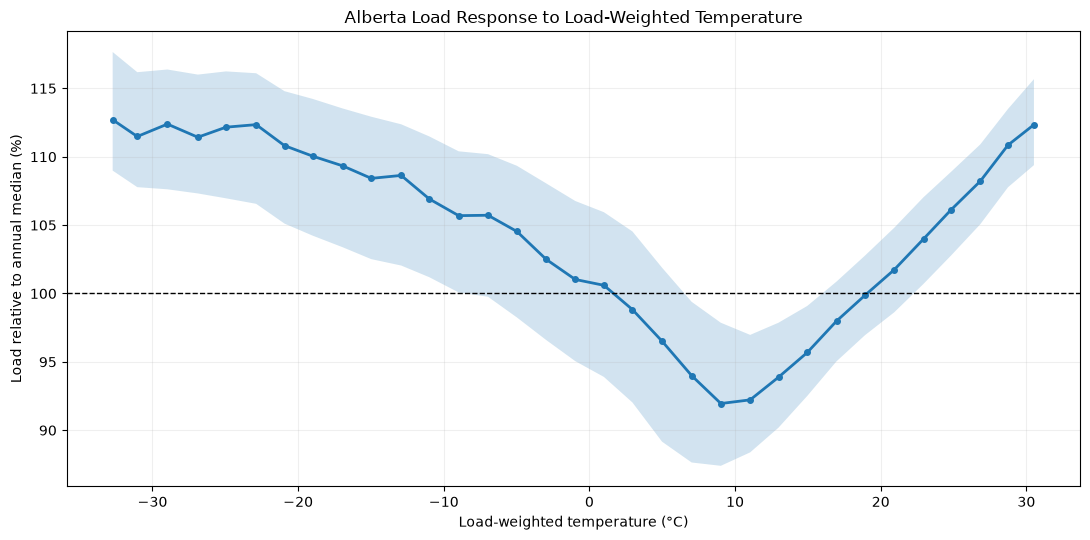

In [11]:
# ---------------------------------------------------------------------
# Plot the temperature-load response
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    temperature_response[
        "median_temperature_c"
    ],
    temperature_response[
        "median_load_index"
    ],
    linewidth=2,
    marker="o",
    markersize=4,
)

ax.fill_between(
    temperature_response[
        "median_temperature_c"
    ],
    temperature_response[
        "load_index_25th_percentile"
    ],
    temperature_response[
        "load_index_75th_percentile"
    ],
    alpha=0.20,
)

ax.axhline(
    100,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Alberta Load Response to "
    "Load-Weighted Temperature"
)
ax.set_xlabel("Load-weighted temperature (°C)")
ax.set_ylabel(
    "Load relative to annual median (%)"
)
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

#### Nonlinear Temperature-Load Response

Alberta load exhibits a clear U-shaped relationship with temperature. Demand is lowest near 9–11°C, at approximately 92% of the annual median, and rises as conditions become either colder or hotter. Load reaches roughly 112% during both extreme cold and extreme heat, consistent with heating and cooling demand.

The response is broader and more persistent on the cold side, while hot-weather demand increases sharply above approximately 20°C. Estimates at the most extreme temperatures are less precise because those conditions occur less frequently.

### 2.2 Annual Stability of the Temperature Response

Absolute temperature bands are compared across years. Each cell reports median load relative to that year’s median load.

A stable physical response should show consistently elevated load during severe cold and, where sufficiently represented, extreme heat. Cells with fewer than 100 observations are suppressed.

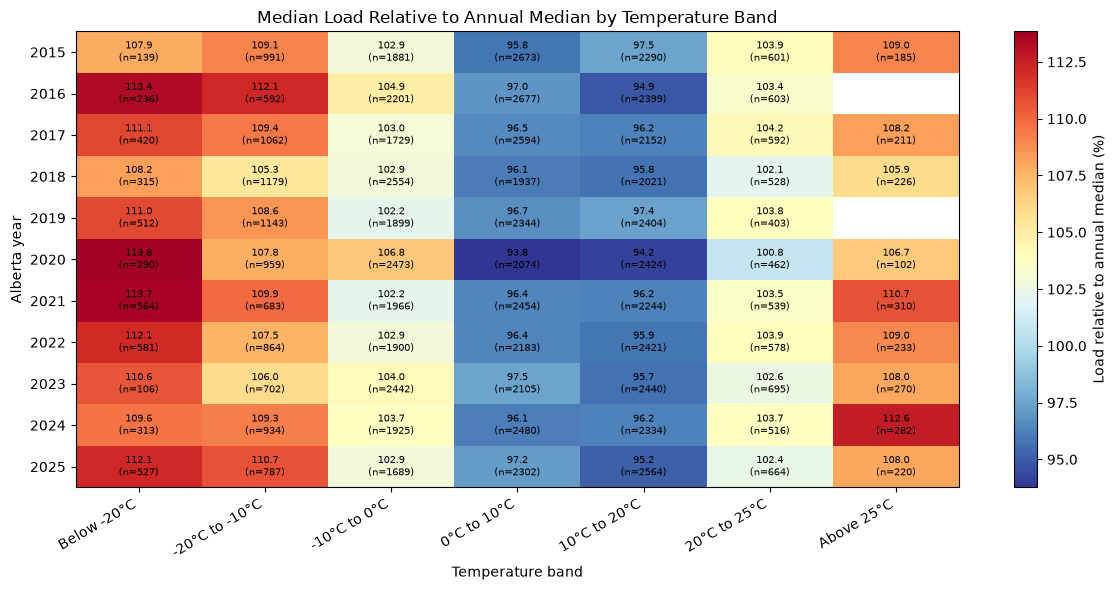

In [12]:
# ---------------------------------------------------------------------
# Test annual stability across absolute temperature bands
# ---------------------------------------------------------------------

TEMPERATURE_BAND_ORDER = [
    "Below -20°C",
    "-20°C to -10°C",
    "-10°C to 0°C",
    "0°C to 10°C",
    "10°C to 20°C",
    "20°C to 25°C",
    "Above 25°C",
]

temperature_band = pd.cut(
    master["load_weighted_temperature_c"],
    bins=[
        -np.inf,
        -20,
        -10,
        0,
        10,
        20,
        25,
        np.inf,
    ],
    labels=TEMPERATURE_BAND_ORDER,
    right=False,
)

annual_temperature_response = (
    pd.DataFrame({
        "year_alberta":
            master["year_alberta"],
        "temperature_band":
            temperature_band,
        "load_index":
            weather_features[
                "load_index_within_year"
            ],
    })
    .dropna()
    .groupby(
        [
            "year_alberta",
            "temperature_band",
        ],
        observed=True,
    )
    .agg(
        hours=("load_index", "size"),
        median_load_index=(
            "load_index",
            "median",
        ),
    )
    .reset_index()
)

annual_temperature_values = (
    annual_temperature_response
    .pivot(
        index="year_alberta",
        columns="temperature_band",
        values="median_load_index",
    )
    .reindex(columns=TEMPERATURE_BAND_ORDER)
)

annual_temperature_counts = (
    annual_temperature_response
    .pivot(
        index="year_alberta",
        columns="temperature_band",
        values="hours",
    )
    .reindex(
        index=annual_temperature_values.index,
        columns=TEMPERATURE_BAND_ORDER,
    )
)

displayed_temperature_values = (
    annual_temperature_values.where(
        annual_temperature_counts.ge(
            MINIMUM_BIN_HOURS
        )
    )
)

fig, ax = plt.subplots(figsize=(12, 6))

image = ax.imshow(
    displayed_temperature_values,
    aspect="auto",
    cmap="RdYlBu_r",
)

ax.set_xticks(
    range(len(TEMPERATURE_BAND_ORDER))
)
ax.set_xticklabels(
    TEMPERATURE_BAND_ORDER,
    rotation=30,
    ha="right",
)

ax.set_yticks(
    range(
        len(
            displayed_temperature_values.index
        )
    )
)
ax.set_yticklabels(
    displayed_temperature_values.index
)

for row in range(
    displayed_temperature_values.shape[0]
):
    for column in range(
        displayed_temperature_values.shape[1]
    ):
        value = displayed_temperature_values.iloc[
            row,
            column,
        ]

        count = annual_temperature_counts.iloc[
            row,
            column,
        ]

        if np.isfinite(value):
            ax.text(
                column,
                row,
                f"{value:.1f}\n"
                f"(n={count:.0f})",
                ha="center",
                va="center",
                fontsize=7,
            )

ax.set_title(
    "Median Load Relative to Annual Median "
    "by Temperature Band"
)
ax.set_xlabel("Temperature band")
ax.set_ylabel("Alberta year")

fig.colorbar(
    image,
    ax=ax,
    label="Load relative to annual median (%)",
)

plt.tight_layout()
plt.show()

#### Stability of the Temperature–Load Relationship

The U-shaped temperature response is consistent across years. Load is generally highest below −20°C, reaching 108–114% of each year’s median, and lowest between 0°C and 20°C, at approximately 94–97%. Demand also rises above 25°C, although these hot-weather estimates are based on fewer observations and are therefore less stable.

This consistency indicates that temperature has a persistent relationship with Alberta demand despite changes in annual load levels and market structure.

### 2.3 Weather Modifiers Beyond Temperature

Temperature is likely to capture most of the direct weather relationship with load. Other variables may add descriptive information, but many are mechanically related to temperature.

The following screen first removes each temperature bin’s median load response, then measures whether humidity, spatial temperature dispersion, temperature changes, wind chill, or heat index remain associated with the residual.

This is a descriptive conditional screen, not a causal or predictive model.

In [13]:
# ---------------------------------------------------------------------
# Screen weather modifiers after removing binned temperature response
# ---------------------------------------------------------------------

modifier_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "temperature_c": master["load_weighted_temperature_c"],
    "load_index": weather_features["load_index_within_year"],
    "humidity_pct": master["load_weighted_relative_humidity_pct"],
    "temperature_spatial_std_c": master["load_temperature_spatial_std_c"],
    "temperature_change_6h_c": master["load_temperature_change_6h_c"],
    "wind_chill_c": master["load_weighted_wind_chill_c"],
    "heat_index_c": master["load_weighted_heat_index_c"],
})

modifier_frame["temperature_bin_c"] = (
    np.floor(
        modifier_frame["temperature_c"] / TEMPERATURE_BIN_WIDTH_C
    ) * TEMPERATURE_BIN_WIDTH_C
)

modifier_frame["expected_load_index_in_bin"] = (
    modifier_frame.groupby(
        ["year_alberta", "temperature_bin_c"]
    )["load_index"].transform("median")
)

modifier_frame["temperature_adjusted_load_index"] = (
    modifier_frame["load_index"] - modifier_frame["expected_load_index_in_bin"]
)

modifier_definitions = {
    "Relative humidity": ("humidity_pct", modifier_frame["humidity_pct"].notna()),
    "Temperature spatial dispersion": ("temperature_spatial_std_c", modifier_frame["temperature_spatial_std_c"].notna()),
    "Six-hour temperature change": ("temperature_change_6h_c", modifier_frame["temperature_change_6h_c"].notna()),
    "Wind chill during cold conditions": ("wind_chill_c", modifier_frame["temperature_c"].le(0) & modifier_frame["wind_chill_c"].notna()),
    "Heat index when reported": ("heat_index_c", modifier_frame["heat_index_c"].notna()),
}

modifier_rows = []

for (label, (column, condition)) in modifier_definitions.items():
    sample = modifier_frame.loc[
        condition,
        [column, "temperature_adjusted_load_index"],
    ].dropna()

    modifier_rows.append({
        "weather_modifier": label,
        "observations": len(sample),
        "coverage_pct": len(sample) / len(master) * 100,
        "spearman_with_temperature_adjusted_load": sample[column].corr(sample["temperature_adjusted_load_index"], method="spearman",),
    })

weather_modifier_screen = pd.DataFrame(modifier_rows)

display(weather_modifier_screen.round(3))

,weather_modifier,observations,coverage_pct,spearman_with_temperature_adjusted_load
0,Relative humidity,96425,100.000,-0.232
1,Temperature spatial dispersion,96425,100.000,0.142
2,Six-hour temperature change,96425,100.000,0.433
3,Wind chill during cold conditions,36544,37.899,0.003
4,Heat index when reported,919,0.953,-0.025


#### Weather Modifiers Beyond Temperature

After accounting for temperature, six-hour temperature change has the strongest remaining association with load (ρ = 0.433), suggesting that recent weather transitions may contain additional demand information. Relative humidity has a modest negative relationship, while spatial temperature dispersion is weakly positive.

Wind chill and heat index show almost no additional monotonic relationship. The heat-index result is especially uncertain because it is reported for less than 1% of observations.

### 2.4 Temperature Changes and Load Ramps

Rapid cooling and warming may matter differently depending on the prevailing temperature state.

This section compares six-hour load changes during rapid cooling, typical temperature movement, and rapid warming. It is a compact descriptive ramp analysis rather than an exhaustive lag-selection exercise.

In [14]:
# ---------------------------------------------------------------------
# Compare temperature changes with load ramps
# ---------------------------------------------------------------------

weather_features['load_change_6h_mw'] = (
    master['ail_mw'].diff(6)
)

temperature_change_percentile = (
    within_year_percentile(master["load_temperature_change_6h_c"])
)

TEMPERATURE_CHANGE_STATE_ORDER = [
    'Rapid cooling',
    'Typical change',
    'Rapid warming',
]

temperature_change_state = pd.Categorical(
    np.select(
        [temperature_change_percentile.le(0.05), temperature_change_percentile.ge(0.95)],
        ["Rapid cooling", "Rapid warming"],
        default = "Typical change",
    ),
    categories = TEMPERATURE_CHANGE_STATE_ORDER,
    ordered = True
)

temperature_ramp_summary = (
    pd.DataFrame({
        "temperature_band": temperature_band,
        "temperature_change_state": temperature_change_state,
        "temperature_change_6h_c": master["load_temperature_change_6h_c"],
        "load_change_6h_mw": weather_features["load_change_6h_mw"]
    })
    .dropna()
    .groupby(
        ["temperature_band", "temperature_change_state"],
        observed=True,
    )
    .agg(
        hours=("load_change_6h_mw", "size"),
        median_temperature_change_c=("temperature_change_6h_c", "median"),
        mean_load_change_mw=("load_change_6h_mw", "mean"),
        median_load_change_mw=("load_change_6h_mw", "median"),
    )
    .reset_index()
)

display(temperature_ramp_summary.round(2))

,temperature_band,temperature_change_state,hours,median_temperature_change_c,mean_load_change_mw,median_load_change_mw
0,Below -20°C,Rapid cooling,13,-7.88,-758.54,-812.0
1,Below -20°C,Typical change,3972,-1.27,-20.96,65.0
2,Below -20°C,Rapid warming,18,10.69,75.94,8.5
3,-20°C to -10°C,Rapid cooling,45,-8.46,-530.60,-614.0
4,-20°C to -10°C,Typical change,9755,-0.97,-1.78,65.0
5,-20°C to -10°C,Rapid warming,96,10.64,17.89,-74.0
6,-10°C to 0°C,Rapid cooling,182,-8.65,-531.57,-580.0
7,-10°C to 0°C,Typical change,22227,-1.01,-23.78,16.0
8,-10°C to 0°C,Rapid warming,244,10.53,-32.25,-90.5
9,0°C to 10°C,Rapid cooling,1473,-9.19,-758.16,-802.0


#### Temperature Changes and Load Ramps

Rapid temperature changes coincide with substantial load ramps, but their direction depends on the prevailing temperature. Above 10°C, rapid warming is associated with rising load—exceeding 1,100 MW in hot conditions—while rapid cooling accompanies large load declines. Similar declines during rapid cooling at colder temperatures suggest that time-of-day and weather-system timing also influence the result.

These relationships are descriptive rather than causal, and estimates for the coldest rapid-change conditions rely on relatively few observations.

#### Section 2 Summary

Alberta’s temperature–load relationship is strongly U-shaped. Load is lowest near 9–11°C and rises during both cold and hot conditions, reaching approximately 112% of the annual median at either extreme. Cold sensitivity is broader and more consistently observed, while hot-weather demand increases sharply above 20°C but is supported by fewer observations. This pattern persists across years after normalizing for annual load levels.

After conditioning on temperature, six-hour temperature change retains the strongest additional relationship with load. Humidity and spatial temperature dispersion add modest information, whereas wind chill and heat index contribute little independently. Rapid warming above 10°C coincides with substantial load increases, while rapid cooling accompanies large declines; however, these relationships may also reflect time-of-day and weather-system timing.

These results establish temperature level and recent temperature change as the principal historical weather indicators of demand. Forecasting applications must replace the realized hourly weather fields with information available from weather forecasts at the intended forecast origin.

## 3. Wind Availability and Variability

### 3.1 Empirical Wind-Power Relationship

Wind generation is normalized by reported wind system capacity to separate weather-driven output from long-term fleet growth.

The analysis compares capacity-weighted 100-metre wind speed with realized wind capacity factor. The resulting curve is an aggregate empirical relationship, not a turbine-level engineering power curve.

Differences between weather-implied output and realized generation may reflect outages, curtailment, transmission constraints, project coverage, wake effects, or measurement differences.

In [20]:
# ---------------------------------------------------------------------
# Build the empirical wind-speed response
# ---------------------------------------------------------------------

wind_frame = pd.DataFrame({
    "wind_speed_100m": master["wind_capacity_weighted_speed_100m"],
    "wind_capacity_factor_pct": weather_features["wind_capacity_factor_pct"],
    "wind_generation_mw": master["wind_system_generation"],
    "wind_capacity_mw": master["wind_system_capacity"],
    "wind_speed_spatial_std": master["wind_speed_100m_spatial_std"]
}).dropna()

wind_frame["wind_speed_bin_ms"] = (
    np.floor(wind_frame["wind_speed_100m"] / WIND_SPEED_BIN_WIDTH_MS)
    * WIND_SPEED_BIN_WIDTH_MS
)

wind_speed_response = (
    wind_frame
    .groupby("wind_speed_bin_ms")
    .agg(
        hours=("wind_capacity_factor_pct", "size"),
        median_wind_speed_ms=("wind_speed_100m", "median"),
        median_capacity_factor_pct=("wind_capacity_factor_pct", "median"),
        capacity_factor_25th_percentile=("wind_capacity_factor_pct", lambda series: series.quantile(0.25)),
        capacity_factor_75th_percentile=("wind_capacity_factor_pct", lambda series: series.quantile(0.75)),
    )
    .reset_index()
)

wind_speed_response = (
    wind_speed_response.loc[wind_speed_response["hours"].ge(MINIMUM_BIN_HOURS)]
)

display(wind_speed_response.round(2))

,wind_speed_bin_ms,hours,median_wind_speed_ms,median_capacity_factor_pct,capacity_factor_25th_percentile,capacity_factor_75th_percentile
1,1.0,2663,1.73,1.46,0.55,3.18
2,2.0,9301,2.58,4.01,2.00,7.22
3,3.0,13957,3.52,9.42,5.55,14.68
4,4.0,15390,4.49,17.81,12.00,24.84
5,5.0,14106,5.49,28.18,21.09,35.90
6,6.0,12021,6.47,39.42,32.04,47.54
7,7.0,9234,7.49,50.97,43.37,58.76
8,8.0,7506,8.46,60.81,52.62,68.60
9,9.0,5173,9.44,68.61,59.76,75.94
10,10.0,3390,10.43,73.37,64.56,80.48


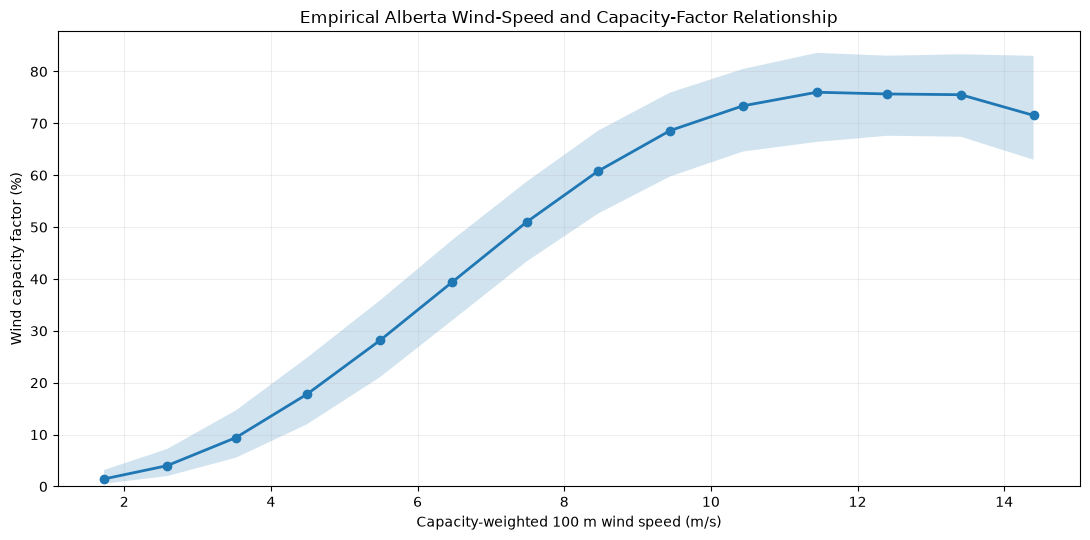

In [21]:
# ---------------------------------------------------------------------
# Plot the empirical wind-power relationship
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    wind_speed_response["median_wind_speed_ms"],
    wind_speed_response["median_capacity_factor_pct"],
    marker="o",
    linewidth=2,
)

ax.fill_between(
    wind_speed_response["median_wind_speed_ms"],
    wind_speed_response["capacity_factor_25th_percentile"],
    wind_speed_response["capacity_factor_75th_percentile"],
    alpha=0.20,
)

ax.set_title(
    "Empirical Alberta Wind-Speed "
    "and Capacity-Factor Relationship"
)
ax.set_xlabel(
    "Capacity-weighted 100 m wind speed (m/s)"
)
ax.set_ylabel("Wind capacity factor (%)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

#### Empirical Wind-Power Relationship

Wind capacity factor follows the expected nonlinear power-curve relationship. Median output rises from approximately 4% at 2.6 m/s to 61% at 8.5 m/s, then plateaus near 75–76% between 11 and 13 m/s. The slight decline at the highest speeds may reflect curtailment, turbine protection, geographic aggregation, or limited observations.

This is a system-level empirical relationship rather than an individual turbine power curve, so variation also reflects outages, turbine characteristics, and differences between measured and site-level wind conditions.

### 3.2 Structural Stability of the Wind Relationship

The wind-speed relationship is repeated across structural market regimes using identical axes.

This tests whether the aggregate power-curve relationship changes as Alberta’s wind fleet expands geographically and technologically. The 2025 regime contains only one year and should be interpreted as preliminary.

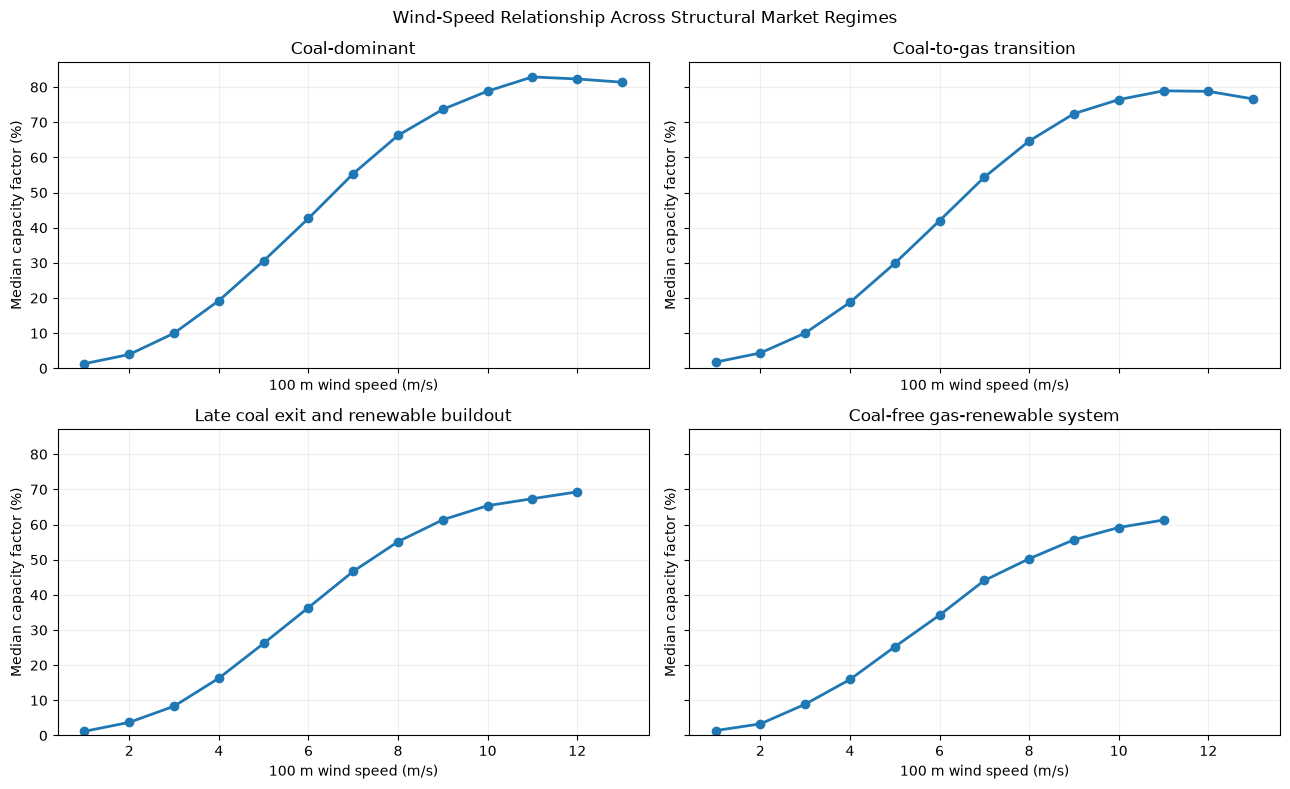

In [22]:
# ---------------------------------------------------------------------
# Compare wind-speed response across structural regimes
# ---------------------------------------------------------------------

wind_regime_response = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "wind_speed_bin_ms": np.floor(master["wind_capacity_weighted_speed_100m"] / WIND_SPEED_BIN_WIDTH_MS) * WIND_SPEED_BIN_WIDTH_MS,
        "wind_capacity_factor_pct": weather_features["wind_capacity_factor_pct"],
    })
    .dropna()
    .groupby(
        ["structural_regime", "wind_speed_bin_ms"],
        observed=True,
    )
    .agg(
        hours=("wind_capacity_factor_pct", "size"),
        median_capacity_factor_pct=("wind_capacity_factor_pct", "median"),
    )
    .reset_index()
)

maximum_wind_cf = (
    wind_regime_response["median_capacity_factor_pct"].max()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    sharex=True,
    sharey=True,
)

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    plot_data = (
        wind_regime_response.loc[
            wind_regime_response["structural_regime"].eq(regime)
            & wind_regime_response["hours"].ge(MINIMUM_BIN_HOURS)
        ]
        .sort_values("wind_speed_bin_ms")
    )

    axis.plot(
        plot_data["wind_speed_bin_ms"],
        plot_data["median_capacity_factor_pct"],
        marker="o",
        linewidth=2,
    )

    axis.set_title(regime)
    axis.set_xlabel("100 m wind speed (m/s)")
    axis.set_ylabel("Median capacity factor (%)")
    axis.set_ylim(0, maximum_wind_cf * 1.05)
    axis.grid(alpha=0.20)

fig.suptitle(
    "Wind-Speed Relationship Across "
    "Structural Market Regimes"
)

plt.tight_layout()
plt.show()

#### Structural Stability of the Wind Relationship

The nonlinear wind-speed relationship persists across all structural regimes, confirming that wind speed remains a stable physical driver of generation. However, capacity factors at comparable wind speeds decline in later regimes: the high-speed plateau falls from roughly 80% in the earlier periods to about 69% during the renewable buildout and 61% in 2025.

This shift may reflect changes in fleet geography, turbine composition, curtailment, outages, capacity reporting, or the relationship between regional weather measurements and newer wind sites. Forecasting models should therefore allow the wind-speed conversion relationship to change over time rather than assuming one fixed historical power curve.

### 3.3 Persistent Low-Wind Conditions

Hours in the bottom 10% of each year’s capacity-weighted wind-speed distribution are grouped into consecutive low-wind episodes.

The episode analysis measures the frequency, duration, and realized wind output associated with persistent weak-wind conditions. It does not define an official wind-drought threshold.

In [25]:
# ---------------------------------------------------------------------
# Construct and summarize low-wind episodes
# ---------------------------------------------------------------------

wind_speed_percentile = (
    within_year_percentile(master["wind_capacity_weighted_speed_100m"])
)

low_wind_event = wind_speed_percentile.le(0.10)

low_wind_episode_id = build_episode_id(low_wind_event)

low_wind_hourly = pd.DataFrame({
    "episode_id": low_wind_episode_id,
    "timestamp_alberta": master["timestamp_alberta"],
    "wind_speed_100m": master["wind_capacity_weighted_speed_100m"],
    "wind_capacity_factor_pct": weather_features["wind_capacity_factor_pct"],
}).dropna(subset=["episode_id"])

low_wind_episodes = (
    low_wind_hourly
    .groupby("episode_id")
    .agg(
        start=("timestamp_alberta", "min"),
        end=("timestamp_alberta", "max"),
        duration_hours=("timestamp_alberta", "size"),
        minimum_wind_speed_ms=("wind_speed_100m", "min"),
        average_wind_speed_ms=("wind_speed_100m", "mean"),
        average_capacity_factor_pct=("wind_capacity_factor_pct", "mean"),
        minimum_capacity_factor_pct=("wind_capacity_factor_pct", "min"),
    )
    .sort_values("duration_hours", ascending=False)
)

low_wind_display = low_wind_episodes.head(20).copy()

numeric_columns = (
    low_wind_display
    .select_dtypes(include="number")
    .columns
)

low_wind_display[numeric_columns] = (
    low_wind_display[numeric_columns].round(2)
)

display(low_wind_display)

,start,end,duration_hours,minimum_wind_speed_ms,average_wind_speed_ms,average_capacity_factor_pct,minimum_capacity_factor_pct
episode_id,,,,,,,
1343.0,2023-05-10 08:00:00-06:00,2023-05-12 17:00:00-06:00,58,1.03,1.86,3.73,0.10
981.0,2021-01-27 20:00:00-07:00,2021-01-29 17:00:00-07:00,46,0.96,1.94,1.00,0.00
328.0,2017-01-23 04:00:00-07:00,2017-01-24 18:00:00-07:00,39,1.31,1.74,0.51,0.02
1332.0,2023-04-12 09:00:00-06:00,2023-04-13 20:00:00-06:00,36,1.55,2.08,3.42,0.14
1289.0,2022-11-08 14:00:00-07:00,2022-11-10 00:00:00-07:00,35,1.73,2.42,1.93,0.25
802.0,2019-11-28 20:00:00-07:00,2019-11-30 06:00:00-07:00,35,1.13,1.94,1.25,0.00
1510.0,2024-07-08 10:00:00-06:00,2024-07-09 13:00:00-06:00,28,1.39,2.29,2.44,0.33
1322.0,2023-03-24 23:00:00-06:00,2023-03-26 02:00:00-06:00,28,1.95,2.43,4.43,1.05
1588.0,2025-01-01 18:00:00-07:00,2025-01-02 21:00:00-07:00,28,2.27,2.58,1.07,0.31


,duration_hours
count,1725.00
mean,5.59
std,4.98
min,1.00
50%,4.00
75%,8.00
90%,11.00
95%,14.80
99%,23.00
max,58.00


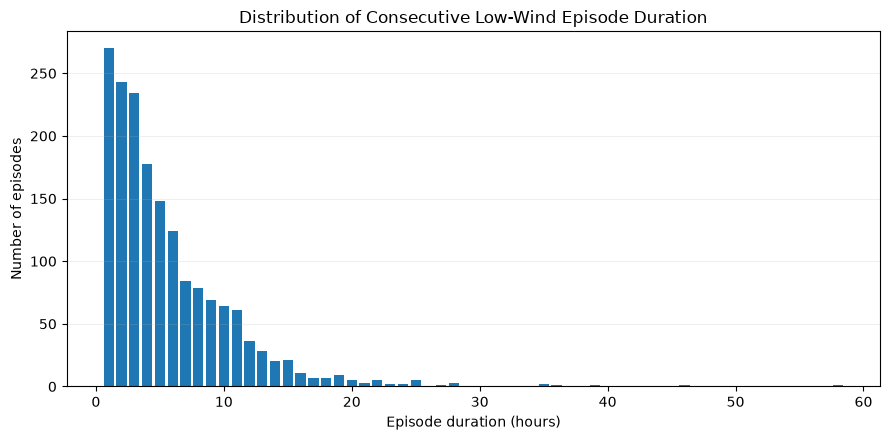

In [26]:
# ---------------------------------------------------------------------
# Summarize low-wind persistence
# ---------------------------------------------------------------------

low_wind_duration_summary = (
    low_wind_episodes["duration_hours"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame("duration_hours")
)

display(low_wind_duration_summary.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))

duration_counts = (
    low_wind_episodes["duration_hours"]
    .value_counts()
    .sort_index()
)

ax.bar(duration_counts.index, duration_counts.values)

ax.set_title(
    "Distribution of Consecutive "
    "Low-Wind Episode Duration"
)
ax.set_xlabel("Episode duration (hours)")
ax.set_ylabel("Number of episodes")
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

#### Persistent Low-Wind Conditions

The 1,725 identified low-wind episodes are strongly right-skewed. A typical event is brief—the median duration is four hours and 75% end within eight hours—but 5% persist for approximately 15 hours or longer, and 1% last at least 23 hours.

The longest episode continued for 58 hours, while several others lasted more than a full day. Average wind capacity factors during these extended events were generally below 5%, confirming that very low wind generation can occasionally persist across multiple operating periods.

### 3.4 Wind Ramps and Geographic Dispersion

Wind-capacity-factor ramps are examined over one- and six-hour horizons. Ramps are normalized by capacity so fleet expansion does not mechanically increase their magnitude.

The analysis also tests whether geographically dispersed wind conditions are associated with smaller or larger aggregate ramps.

In [27]:
# ---------------------------------------------------------------------
# Summarize wind-capacity-factor ramps
# ---------------------------------------------------------------------

wind_ramp_rows = []

for horizon in [1, 3, 6, 12]:
    ramp = (weather_features["wind_capacity_factor_pct"].diff(horizon))

    wind_ramp_rows.append({
        "horizon_hours": horizon,
        "observations": ramp.notna().sum(),
        "mean_change_pct_points": ramp.mean(),
        "median_change_pct_points": ramp.median(),
        "mean_absolute_change_pct_points": ramp.abs().mean(),
        "90th_percentile_absolute_change": ramp.abs().quantile(0.90),
        "99th_percentile_absolute_change": ramp.abs().quantile(0.99),
    })

wind_ramp_summary = pd.DataFrame(wind_ramp_rows)

display(wind_ramp_summary.round(2))

,horizon_hours,observations,mean_change_pct_points,median_change_pct_points,mean_absolute_change_pct_points,90th_percentile_absolute_change,99th_percentile_absolute_change
0,1,96424,-0.0,-0.03,3.31,7.69,15.59
1,3,96422,-0.0,-0.09,7.82,18.02,34.44
2,6,96419,-0.0,-0.16,12.43,28.23,49.89
3,12,96413,-0.0,-0.07,17.59,39.15,63.51


In [28]:
# ---------------------------------------------------------------------
# Compare ramp magnitude across wind-dispersion states
# ---------------------------------------------------------------------

wind_dispersion_percentile = (
    within_year_percentile(master["wind_speed_100m_spatial_std"])
)

WIND_DISPERSION_STATE_ORDER = [
    "Low dispersion",
    "Typical dispersion",
    "High dispersion",
]

wind_dispersion_state = pd.Categorical(
    np.select(
        [wind_dispersion_percentile.le(0.20), wind_dispersion_percentile.ge(0.80)],
        ["Low dispersion", "High dispersion"],
        default="Typical dispersion",
    ),
    categories=WIND_DISPERSION_STATE_ORDER,
    ordered=True,
)

wind_dispersion_ramp_summary = (
    pd.DataFrame({
        "dispersion_state": wind_dispersion_state,
        "absolute_wind_cf_ramp_1h": weather_features["wind_capacity_factor_pct"].diff().abs(),
        "absolute_wind_cf_ramp_6h": weather_features["wind_capacity_factor_pct"].diff(6).abs(),
    })
    .dropna()
    .groupby(
        "dispersion_state",
        observed=True,
    )
    .agg(
        hours=("absolute_wind_cf_ramp_1h", "size"),
        median_absolute_ramp_1h=("absolute_wind_cf_ramp_1h", "median"),
        ramp_90th_percentile_1h=("absolute_wind_cf_ramp_1h", lambda series: series.quantile(0.90)),
        median_absolute_ramp_6h=("absolute_wind_cf_ramp_6h", "median"),
        ramp_90th_percentile_6h=("absolute_wind_cf_ramp_6h", lambda series: series.quantile(0.90)),
    )
)

display(wind_dispersion_ramp_summary.round(2))

,hours,median_absolute_ramp_1h,ramp_90th_percentile_1h,median_absolute_ramp_6h,ramp_90th_percentile_6h
dispersion_state,,,,,
Low dispersion,19281,1.55,6.85,7.06,26.65
Typical dispersion,57845,2.44,7.93,9.63,28.85
High dispersion,19293,2.49,7.75,9.65,27.76


#### Wind Ramps and Geographic Dispersion

Wind capacity-factor changes are approximately balanced around zero, but their magnitude grows materially with the forecast horizon. The mean absolute change increases from 3.3 percentage points over one hour to 12.4 points over six hours and 17.6 points over twelve hours. At the six-hour horizon, the largest 10% of changes exceed 28 percentage points and the largest 1% approach 50 points.

Low spatial wind dispersion is associated with somewhat smaller typical ramps. However, typical- and high-dispersion conditions produce very similar ramp distributions, indicating that spatial dispersion alone provides limited separation of major wind-generation changes.

## 4. Solar Availability and Variability

### 4.1 Irradiance and Solar Capacity Factor

Solar analysis begins at the solar-generation reporting boundary and is restricted to daylight hours.

Solar generation is normalized by reported solar system capacity. The principal relationship compares capacity-weighted irradiance with realized solar capacity factor.